# Load ERA5-Land Data

In [1]:
# auto reload modified modules
%load_ext autoreload
%autoreload 2
import sys
WORK_DIR = "/home/research/jenzheng/documents/kai/research/eta/eta"
sys.path.append(WORK_DIR)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from plot_utils import plot_setting, plot_nfields 
from utils import *
import torch
import torch.nn as nn
from tqdm import tqdm
from kde import get_data_pdf
plot_setting()

# Load the cropped data
file_path = WORK_DIR + '/data/ERA5/era5land_USA_SouthEast_1999-2023_dailymax.nc'
ds = xr.open_dataset(file_path, engine='netcdf4')

# Extract the 'tp' variable (Total Precipitation)
tp = ds['tp']

# Convert to a NumPy array and multiply by 1000 (meter to millimeter)
tp_numpy = tp.values * 1000
# 
# Check if there are any NaN values
has_nan = np.isnan(tp_numpy).any()
# print(f"Contains NaN values: {has_nan}")

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Downsample Data

In [2]:
# Downsampling by a factor of 2 for each spatial dimension
ds_fact = 10
tp_ds_numpy = tp_numpy[:, ::ds_fact, ::ds_fact]  # (9050, 40, 80)

# Data Preprocessing


In [ ]:
max_values_original = np.max(tp_numpy, axis=(1, 2))

# max_values_original will have shape (9050,)
print(max_values_original.shape)

# Sort max_values and get the indices that would sort the array
sorted_indices_original = np.argsort(max_values_original)
print(0 in sorted_indices_original)

# Use the sorted_indices to get the sorted max_values
sorted_max_values_original = max_values_original[sorted_indices_original]

# trim the tail
trim_tail_thresh = 240
num_trim_days = len(sorted_max_values_original[sorted_max_values_original > trim_tail_thresh])
trim_days = sorted_indices_original[-num_trim_days:]
sorted_max_values_trim = sorted_max_values_original[:-num_trim_days]
sorted_indices_trim = sorted_indices_original[:-num_trim_days]
print("Trimmed Days: ", trim_days)
print("Trimmed Values: ", sorted_max_values_original[-num_trim_days:])

kept_days = np.delete(np.arange(len(tp_numpy)), trim_days)
tp_trim_numpy = tp_numpy[kept_days]
tp_trim_ds_numpy = tp_ds_numpy[kept_days]
tp_trim_tensor = torch.tensor(tp_trim_numpy)
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy)
print(tp_trim_ds_tensor.shape)
print(tp_trim_tensor.shape)

# Select Training Data

In [11]:
import torch.optim as optim
from rich.progress import Progress
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
import os
import gc

# Convert numpy arrays to PyTorch tensors and move to GPU
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Add channel dimension
tp_trim_tensor = torch.tensor(tp_trim_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Full-resolution target

# Use 20% of the data (5 years) for training
num_years = 0.5
portion = num_years/25
train_size = int(portion * len(tp_trim_ds_tensor))
train_input = tp_trim_ds_tensor[:train_size]
train_target = tp_trim_tensor[:train_size]

# use full data to select the best MSE model for baseline comparison
test_input = deepcopy(tp_trim_ds_tensor)
test_target = deepcopy(tp_trim_tensor)

# move data to device
train_input = train_input.to(device)
train_target = train_target.to(device)
test_input = test_input.to(device)
test_target = test_target.to(device)

# Create DataLoader for batch processing
batch_size = 64
train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=25*batch_size, shuffle=False)

print(train_input.shape)
print(train_target.shape)
print(test_input.shape)
print(test_target.shape)

torch.Size([180, 1, 8, 16])
torch.Size([180, 1, 80, 160])
torch.Size([9044, 1, 8, 16])
torch.Size([9044, 1, 80, 160])


# Training Data v.s. Full Data PDF

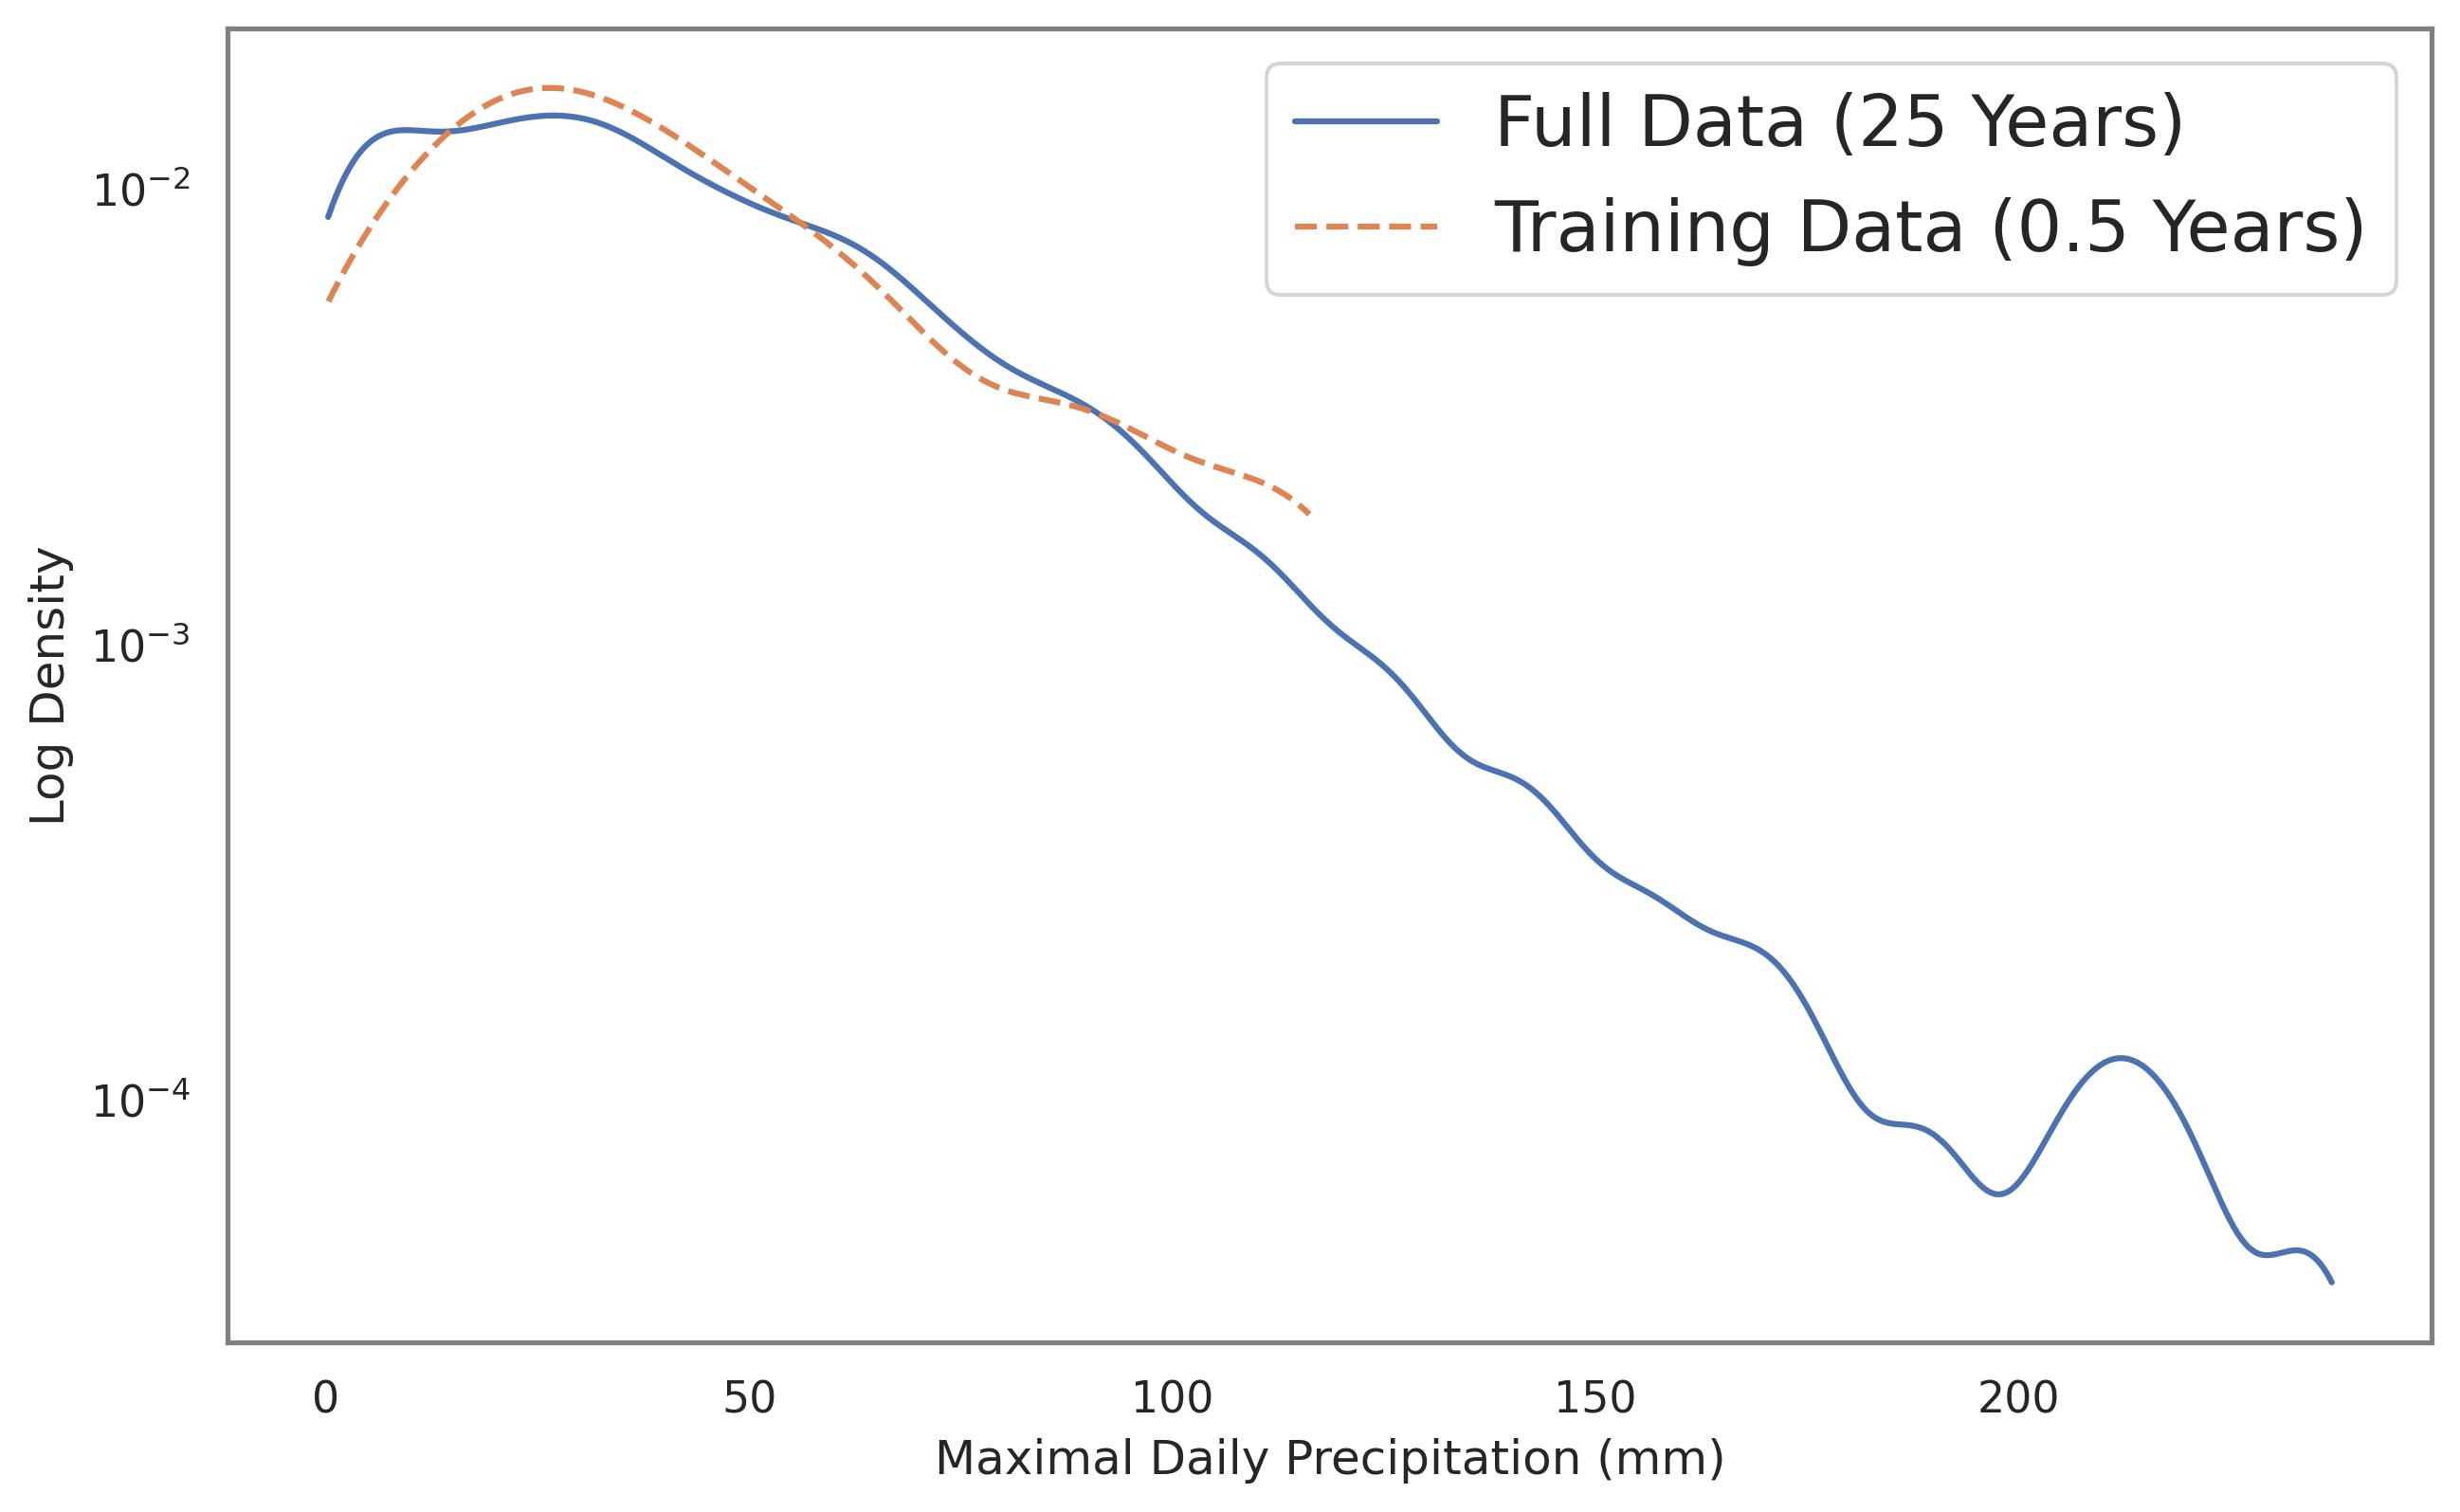

In [12]:
train_max_values = np.max(tp_trim_numpy[:train_size], axis=(1, 2))
y_eval_tp_train, py_tp_train, _ = get_data_pdf(data=torch.tensor(train_max_values), data_all=torch.tensor(train_max_values))

# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=300)

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label="Full Data (25 Years)")
plt.plot(y_eval_tp_train, py_tp_train, label=f"Training Data ({num_years} Years)", linestyle='--')

# Add plot labels and title
plt.xlabel("Maximal Daily Precipitation (mm)")
plt.ylabel("Log Density")
# plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.yscale('log')
plt.legend(prop={"size" : 18})

# Preprocess Generative Model Training Data

In [13]:
# preprocess data 
def get_hires_dgm_train(num_years):
    portion = num_years/25
    train_size = int(portion * len(tp_trim_ds_tensor))
    dgm_train = tp_trim_numpy[:train_size]
    dgm_train = np.clip(dgm_train, 1e0, None)
    dgm_train = np.log(dgm_train)
    train_mean = dgm_train.mean()
    train_std = dgm_train.std()
    dgm_train = (dgm_train - train_mean) / train_std
    inverse_transform = lambda x : np.exp(x*train_std + train_mean)
    return dgm_train, inverse_transform

def get_lores_dgm_train(num_years):
    portion = num_years/25
    train_size = int(portion * len(tp_trim_ds_tensor))
    dgm_train = tp_trim_ds_numpy[:train_size]
    dgm_train = np.clip(dgm_train, 1e0, None)
    dgm_train = np.log(dgm_train)
    train_mean = dgm_train.mean()
    train_std = dgm_train.std()
    dgm_train = (dgm_train - train_mean) / train_std
    inverse_transform = lambda x : np.exp(x*train_std + train_mean)
    return dgm_train, inverse_transform

In [14]:
def max_pairwise_distance(input_data):
    """
    Computes the maximum pairwise Euclidean distance among all images in ddpm_train
    using an iterative approach to save memory.

    Parameters:
    - ddpm_train (np.ndarray): Array of shape (9044, 8, 16)

    Returns:
    - max_distance (float): The maximum Euclidean distance found among all pairs
    """
    n_samples, height, width = input_data.shape
    data = input_data.reshape(n_samples, height * width)
    max_distance = 0.0
    
    for i in range(n_samples):
        if i % 1000 == 0 and i > 0:
            print(f"Processed {i} / {n_samples} samples...")
        # Compute distances between the i-th sample and all subsequent samples
        diffs = data[i+1:] - data[i]
        dists = np.linalg.norm(diffs, axis=1)
        if dists.size > 0:
            current_max = dists.max()
            if current_max > max_distance:
                max_distance = current_max
    
    print(f"The maximum pairwise Euclidean distance is: {max_distance}")
    return max_distance


# beta_max = max_pairwise_distance(ddpm_train)
# print(ddpm_train.shape)

# Flow Matching

In [15]:
from models import WrappedModel
from flow_matching.solver import ODESolver

def dopri5_step(v, x, t, h):
    """
    Performs one integration step using the Dormand-Prince 5th order method.
    
    Args:
        v: Velocity field function v(x, t) that returns dx/dt.
        x: Current state tensor.
        t: Current time (float).
        h: Step size (float).
    
    Returns:
        x_next: Updated state after one step.
    """
    # Compute the stages
    k1 = v(x, t)
    k2 = v(x + h*(1/5) * k1, t + h/5)
    k3 = v(x + h*(3/40 * k1 + 9/40 * k2), t + 3*h/10)
    k4 = v(x + h*(44/45 * k1 - 56/15 * k2 + 32/9 * k3), t + 4*h/5)
    k5 = v(x + h*(19372/6561 * k1 - 25360/2187 * k2 + 64448/6561 * k3 - 212/729 * k4), t + 8*h/9)
    k6 = v(x + h*(9017/3168 * k1 - 355/33 * k2 + 46732/5247 * k3 + 49/176 * k4 - 5103/18656 * k5), t + h)
    
    # Update state using the weighted combination for the 5th order solution
    x_next = x + h * (35/384 * k1 + 500/1113 * k3 + 125/192 * k4 - 2187/6784 * k5 + 11/84 * k6)
    return x_next

def dopri5_fm_sampling(model, step_size, nsamples, batch_size, image_size):
    """
    dopri5 ODE solver for flow matching.
    
    The ODE defined by the velocity field model(x, t) is integrated from t=0 to t=1.
    The initial condition is sampled from a standard Gaussian.
    
    Args:
        model: A callable velocity field function f(x, t) returning dx/dt.
        step_size: Fixed integration step size (float). For example, 0.01.
        nsamples: Total number of samples to generate (int).
        batch_size: Number of samples processed per batch (int).
        image_size: Tuple (H, W, C) defining the height, width, and number of channels.
        
    Returns:
        Tensor of shape (nsamples, C, H, W) containing the generated samples.
    """
    H, W, C = image_size  # Provided as (H, W, C)
    
    # Determine the device from the model parameters (if available) or default
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Calculate the number of integration steps from t=0 to t=1
    num_steps = int(1.0 / step_size)
    
    samples_list = []
    n_batches = nsamples // batch_size + (1 if nsamples % batch_size != 0 else 0)
    
    model.eval()
    with torch.no_grad():
        for i in range(n_batches):
            # Handle the last batch if it's smaller than batch_size
            current_batch_size = batch_size if i < n_batches - 1 else nsamples - batch_size * i
            
            # Initialize samples with a standard Gaussian
            x = torch.randn(current_batch_size, C, H, W, device=device)
            t = torch.zeros(x.shape[0], device=device)
            # Integrate from t=0 to t=1 using fixed steps
            print(f'Batch {i+1}')
            for _ in tqdm(range(num_steps)):
                x = dopri5_step(model, x, t, step_size)
                t += step_size
            samples_list.append(x)
    
    # Concatenate all batches and ensure we return exactly nsamples
    samples = torch.cat(samples_list, dim=0)
    return samples[:nsamples]

# Big Flow Matching Loop

In [20]:
from models import UNet
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from tqdm import tqdm
import os
import gc
import warnings # To avoide meshgrid warning
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

# Define model parameters
image_channels = 1
n_channels = 16
ch_mults = (1, 2, 2, 4)
is_attn = (False, False, True, True)
n_blocks = 1

ONLY_SAMPLING = False

num_year_list = [25]
epoch_list = [100]
batch_size_list = [128]
step_list = [200]
for num_years, epochs, train_batch_size, nsteps in zip(num_year_list, epoch_list, batch_size_list, step_list):
    
    # checkpoint
    save_path = f"./models/fm/hires-fm-unet{n_channels}-{num_years}yr-{epochs}epoch-{train_batch_size}bsize.pth"
    print(save_path)
    # training data
    fm_train, inverse_transform = get_hires_dgm_train(num_years)
    
    if not ONLY_SAMPLING:
        # training
        # velocity field
        model = UNet(image_channels=image_channels, n_channels=n_channels,
                        ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
        model = torch.nn.DataParallel(model)#, device_ids=[3])
        model = model.to(DEVICE)

        # instantiate an affine path object
        path = AffineProbPath(scheduler=CondOTScheduler())

        # training hyperparams
        lr = 3e-4

        # training modules
        optimizer = torch.optim.Adam(model.parameters(), lr=lr) 
        cfm_loss = nn.MSELoss()

        # training data
        fm_train, inverse_transform = get_hires_dgm_train(num_years)
        fm_train = torch.tensor(fm_train)
        fm_train = fm_train.unsqueeze(1)
        dataset = TensorDataset(fm_train)
        train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True, num_workers=1, pin_memory=True)

        # start training
        model.train()
        best_loss = float('inf')
        for epoch in tqdm(range(epochs)):
            cumulative_loss = 0
            for batch_idx, x_1 in enumerate(train_loader):
                optimizer.zero_grad() 

                # sample x0
                x_1 = x_1[0].to(DEVICE)
                x_0 = torch.randn_like(x_1).to(DEVICE)

                # sample time
                t = torch.rand(x_1.shape[0]).to(DEVICE) 

                # sample probability path
                path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

                # flow matching l2 loss
                loss = cfm_loss(model(path_sample.x_t,path_sample.t), path_sample.dx_t)
                cumulative_loss += loss.item()

                # optimizer step
                loss.backward() # backward
                optimizer.step() # update

            epoch_loss = cumulative_loss / (batch_idx+1)
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                torch.save(model.state_dict(), save_path)
    
    
    # sampling
    model = UNet(image_channels=image_channels, n_channels=n_channels,
            ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
    model = torch.nn.DataParallel(model)#, device_ids=[3])
    model.load_state_dict(torch.load(save_path))
    model = model.to(DEVICE)
    
    img_size = (80,160,1)
    step_size = 1/nsteps
    nsamples = 9044
    batch_size = 9044  # batch size
    sampled_images = dopri5_fm_sampling(model, 
                                        step_size, 
                                        nsamples, 
                                        batch_size, 
                                        img_size)
    sampled_images = sampled_images.squeeze().cpu().numpy()
    sampled_images = inverse_transform(sampled_images)
    save_path_samples = f"./samples/{nsamples}samples-hires-fm-{nsteps}step-unet{n_channels}-{num_years}yr-{epochs}epoch.npy"
    print(save_path_samples)
    np.save(save_path_samples, sampled_images)    

./models/fm/hires-fm-unet16-25yr-100epoch-128bsize.pth


100%|██████████| 100/100 [51:11<00:00, 30.72s/it]


Batch 1


100%|██████████| 200/200 [15:47<00:00,  4.74s/it]


./samples/9044samples-hires-fm-200step-unet16-25yr-100epoch.npy


# Training

In [ ]:
## Train Flow Matching
from models import UNet
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from tqdm import tqdm
import os
# global_seed(40)

# To avoide meshgrid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

# Define model parameters
image_channels = 1
n_channels = 16
ch_mults = (1, 2, 2, 4)
is_attn = (False, False, True, True)
n_blocks = 1

# velocity field
model = UNet(image_channels=image_channels, n_channels=n_channels,
                ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
model = torch.nn.DataParallel(model)#, device_ids=[3])
model = model.to(DEVICE)

# instantiate an affine path object
path = AffineProbPath(scheduler=CondOTScheduler())

# training hyperparams
train_batch_size = 16
lr = 3e-4
epochs = 100
print_every = 1

# training modules
optimizer = torch.optim.Adam(model.parameters(), lr=lr) 
cfm_loss = nn.MSELoss()

# training data
num_years = 2.5
fm_train, inverse_transform = get_hires_dgm_train(num_years)
fm_train = torch.tensor(fm_train)
fm_train = fm_train.unsqueeze(1)
dataset = TensorDataset(fm_train)
train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True, num_workers=1, pin_memory=True)

In [ ]:
# checkpoint
save_path = f"./models/fm/hires-fm-unet{n_channels}-{num_years}yr-{epochs}epoch.pth"
print(save_path)

# seed
# global_seed(40)

# start training
model.train()
best_loss = float('inf')
for epoch in tqdm(range(epochs)):
    cumulative_loss = 0
    for batch_idx, x_1 in enumerate(train_loader):
        optimizer.zero_grad() 

        # sample x0
        x_1 = x_1[0].to(DEVICE)
        x_0 = torch.randn_like(x_1).to(DEVICE)
    
        # sample time
        t = torch.rand(x_1.shape[0]).to(DEVICE) 
    
        # sample probability path
        path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)
    
        # flow matching l2 loss
        loss = cfm_loss(model(path_sample.x_t,path_sample.t), path_sample.dx_t)
        cumulative_loss += loss.item()
        
        # optimizer step
        loss.backward() # backward
        optimizer.step() # update
        
    epoch_loss = cumulative_loss / (batch_idx+1)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), save_path)
        
    if (epoch) % print_every==0:
        print("\tEpoch", epoch + 1, "complete!", "\tCFM Loss: ", epoch_loss)
print("Finish!!")

# Sampling

In [16]:
from models import UNet

# Define model parameters
n_channels = 16
epochs = 100
load_path = f"./models/fm/hires-fm-unet{n_channels}-{num_years}yr-{epochs}epoch.pth"
model = UNet(image_channels=image_channels, n_channels=n_channels,
            ch_mults=ch_mults, is_attn=is_attn, n_blocks=n_blocks)
model = torch.nn.DataParallel(model, device_ids=[3])
model.load_state_dict(torch.load(load_path))
device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

img_size = (8,16,1)
img_size = (80,160,1)
nspaces = 100
step_size = 1/nspaces
nsamples = 9044
batch_size = 2000  # batch size
sampled_images = dopri5_fm_sampling(model, 
                                    step_size, 
                                    nsamples, 
                                    batch_size, 
                                    img_size)

sampled_images = sampled_images.squeeze().cpu().numpy()
sampled_images = inverse_transform(sampled_images)



In [19]:
# save samples
save_path_samples = f"./samples/{nsamples}samples-hires-fm-unet{n_channels}-{num_years}yr-{epochs}epoch.npy"
print(save_path_samples)
np.save(save_path_samples, sampled_images)